In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [17]:
print("Dataset Shape:",df.shape)

Dataset Shape: (1000, 9)


In [18]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [19]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [20]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dtype

dtype('<M8[ns]')

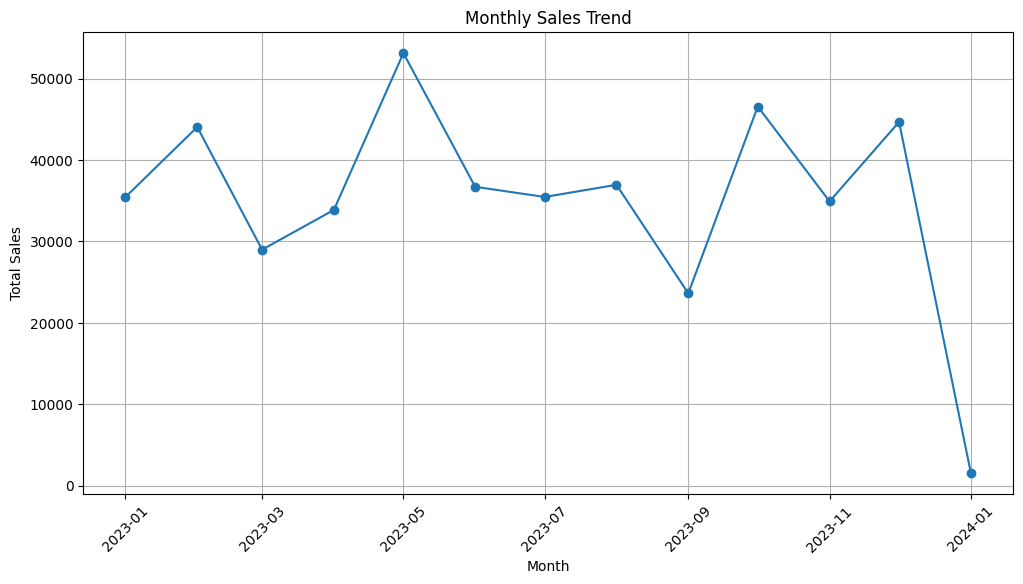

In [21]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### OBSERVATION

- Monthly sales fluctuate throughout the year.
- The highest sales are recorded in "MAY 2023".
- The lowest sales are observed in "JANUARY 2024".
- Sales increase noticeably during "OCTOBER" and "DECEMBER", indicating possible seasonal demand.
- Overall, the sales trend is not constant and shows fluctuations across different months.

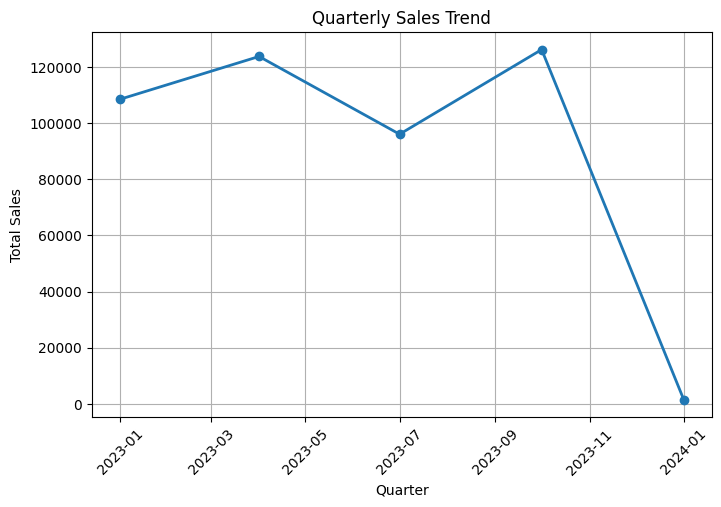

In [22]:
df["Quarter"] = df["Date"].dt.to_period("Q")
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()
quarterly_sales.index = quarterly_sales.index.to_timestamp()

plt.figure(figsize=(8,5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o', linewidth=2)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

### Observation

- Quarterly sales fluctuate throughout the year.
- Sales are highest in **Q4 2023**, followed closely by **Q2 2023**.
- **Q3 2023** records comparatively lower sales.
- The sharp decline in **Q1 2024** is due to limited data available for that quarter in the dataset.
- Overall, sales show seasonal variations across different quarters.

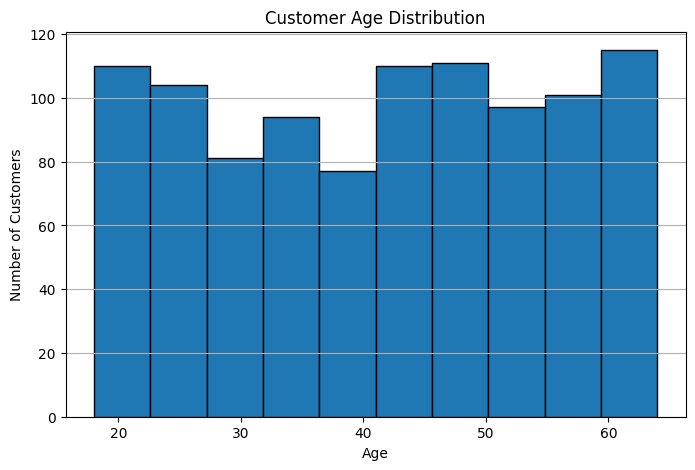

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.grid(axis='y')
plt.show()

### Observation

- Most customers belong to the middle-age group.
- Customer ages are distributed across different age ranges.
- No unusual age values or extreme outliers are observed.
- The dataset represents customers from a wide range of age groups.

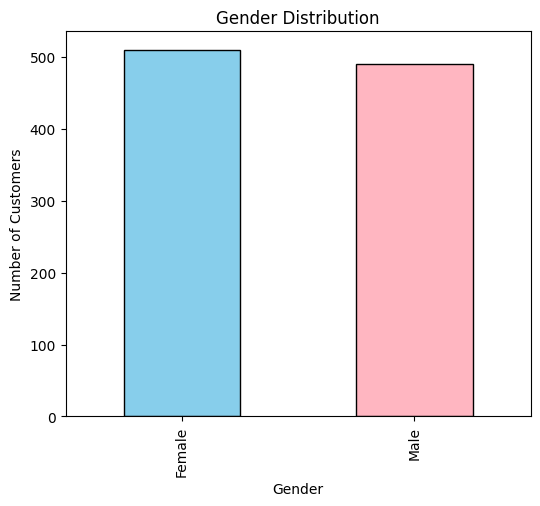

In [24]:
plt.figure(figsize=(6,5))

df["Gender"].value_counts().plot(
    kind="bar",
    color=["skyblue", "lightpink"],
    edgecolor="black"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- The dataset contains both male and female customers.
- The gender distribution is fairly balanced.
- Both customer groups contribute significantly to the overall sales.

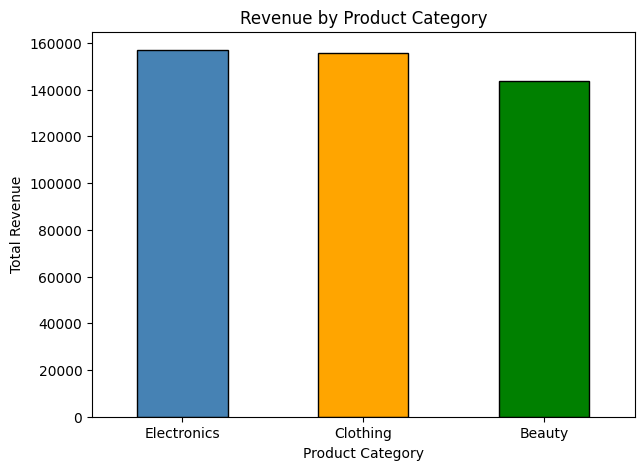

In [25]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
category_sales.plot(kind="bar", color=["steelblue", "orange", "green"], edgecolor="black")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.show()

### Observation

- Product categories contribute differently to total revenue.
- The category with the highest bar generates the highest revenue.
- The category with the lowest bar contributes comparatively less.
- These insights can help businesses prioritize inventory and marketing strategies.

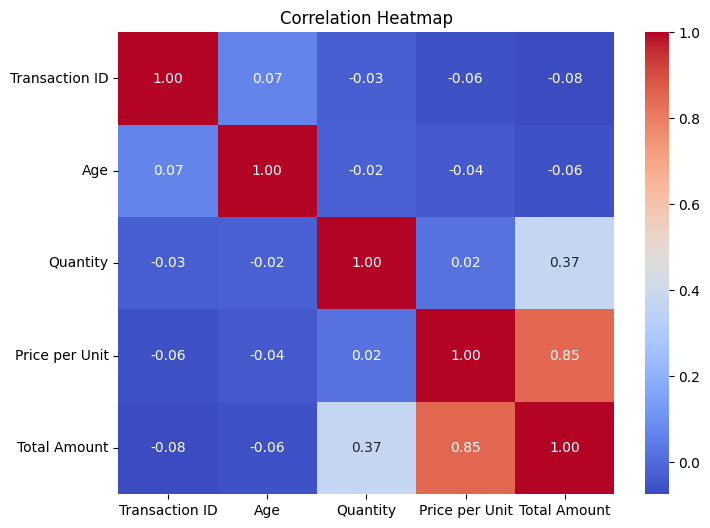

In [26]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observation

- Total Amount has a positive correlation with Quantity and Price per Unit.
- Age shows a weak correlation with sales-related variables.
- Quantity and Price per Unit have a moderate relationship with Total Amount.
- The heatmap helps identify relationships among numerical features.

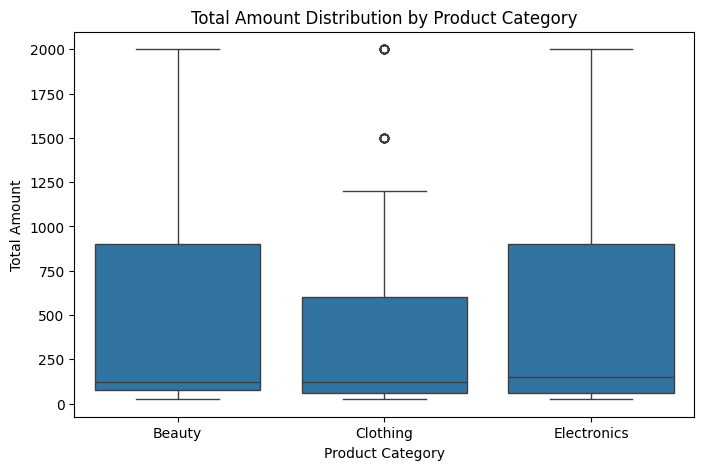

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Product Category', y='Total Amount', data=df)

plt.title("Total Amount Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")

plt.show()

### Observation

- The box plot shows how customer spending varies across different product categories.
- Some categories have higher spending variability than others.
- A few high-value purchases appear as potential outliers.
- This visualization helps identify customer purchasing patterns beyond average revenue.

# Conclusion

1. Electronics and Clothing generate the highest overall revenue, making them key product categories for the business.

2. Customer spending varies across product categories, with some high-value purchases contributing significantly to revenue.

3. Price per Unit has a stronger influence on Total Amount than Quantity, suggesting that promoting premium products could increase overall sales.